In [ ]:
"This notebook is for calculating single cell RNA velocity with Dynamo."

In [1]:
import dynamo as dyn
import numpy as np
from scipy import stats,signal
from matplotlib import pyplot as plt
from scipy import sparse
from sklearn.neighbors import KernelDensity
import networkx as nx
import os
from numpy.random import randint

In [3]:
result_path='result/'
gene_arr=np.load(result_path+'EG_bin_genes.npy',allow_pickle=True)
dim_n=10
adata=dyn.read(result_path+'EG_ori_bin.h5ad')
t_list = ['Pre-endocrine', 'Ductal', 'Alpha', 'Ngn3 high EP', 'Delta', 'Beta', 'Ngn3 low EP', 'Epsilon']

/home/csb/Saloni/CPT_GRN_analysis/.venv/lib/python3.10/site-packages/anndata/__init__.py:55: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


|-----? dynamo.preprocessing.deprecated is deprecated.
|-----> recipe_monocle_keep_raw_layers_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_raw_layers_key=True
|-----> apply Monocole recipe to adata...
|-----> ensure all cell and variable names unique.
|-----> ensure all data in different layers in csr sparse matrix format.
|-----> ensure all labeling data properly collapased
|-----> filtering cells...
|-----> 3696 cells passed basic filters.
|-----> filtering gene...
|-----> 580 genes passed basic filters.
|-----> calculating size factor...
|-----? only 580 genes passed basic filtering, but you requested 2000 genes for feature selection. Try lowering the gene selection stringency: {'min_expr_cells': 0, 'min_expr_avg': 0, 'max_expr_avg': inf, 'svr_gamma': None, 'winsorize': False, 'winsor_perc': (1, 99.5), 'sort_inverse': False}
|-----> selecting genes in layer: X, sort method: SVR...
|-----> Discarding genes that failed the filtering...
|-----> size fact

estimating gamma: 100%|██████████| 737/737 [00:09<00:00, 80.93it/s] 



╭─ SUMMARY: dynamics ────────────────────────────────────────────────╮
│  Duration: 14.9409s                                                │
│  Shape:    3,696 x 737 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● VAR    │ ✚ use_for_dynamics (bool)                              │
│                                                                    │
│  ● UNS    │ ✚ dynamics                                             │
│           │ ✚ vel_params_names                                     │
│                                                                    │
│  ● OBSP   │ ✚ moments_con (sparse matrix, 3696x3696)               │
│                                                                    │
│  ● LAYERS │ ✚ M_s (sparse matrix, 3696x737)                        │
│    

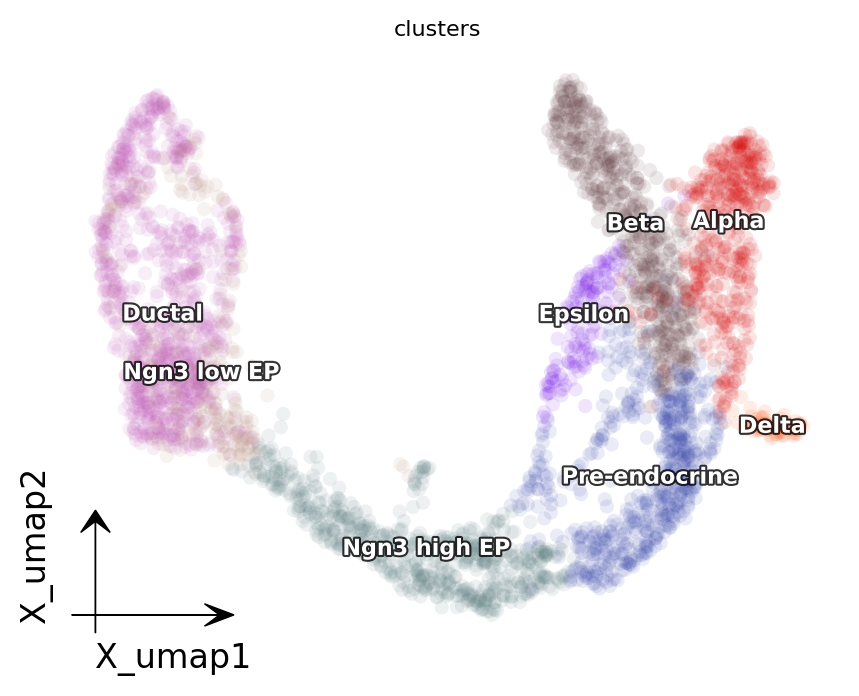

In [4]:
dyn.pp.recipe_monocle(adata,keep_filtered_genes=False,keep_filtered_cells=True)

dyn.tl.dynamics(adata,assumption_mRNA='auto')
dyn.tl.reduceDimension(adata)
dyn.pl.umap(adata, color='clusters',pointsize=0.1)

In [5]:
dyn.tl.cell_velocities(
    adata,
    method='fp',
    basis='pca',
    correct_density=False
)

/home/csb/Saloni/CPT_GRN_analysis/.venv/lib/python3.10/site-packages/dynamo/tools/utils.py:2622: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if np.all(vel_params_df.gamma_r2.values is None) or np.all(vel_params_df.gamma_r2.values == ""):


|-----> [projecting velocity vector to low dimensional embedding] in progress: 51.0552%

/home/csb/Saloni/CPT_GRN_analysis/.venv/lib/python3.10/site-packages/dynamo/tools/Markov.py:989: RuntimeWarning: invalid value encountered in divide
  self.Q[:, i] /= np.sum(self.Q[:, i])


|-----> [projecting velocity vector to low dimensional embedding] in progress: 100.0000%|-----> [projecting velocity vector to low dimensional embedding] completed [0.2728s]
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected

╭─ SUMMARY: cell_velocities ─────────────────────────────────────────╮
│  Duration: 3.4707s                                                 │
│  Shape:    3,696 x 737 (Unchanged)                                 │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● VAR    │ ✚ use_for_transition (bool)                            │
│                                                                    │
│  ● UNS    │ ✚ grid_velocity_pca                                    │
│                                                                    │
│  ● OBSP   │ ✚

AnnData object with n_obs × n_vars = 3696 × 737
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'Size_Factor', 'initial_cell_size', 'ntr', 'cell_cycle_phase'
    var: 'highly_variable_genes', 'nCells', 'nCounts', 'pass_basic_filter', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics', 'use_for_transition'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'pp', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'pca_fit', 'feature_selection', 'cell_phase_order', 'cell_phase_genes', 'history_log', 'vel_params_names', 'dynamics', 'grid_velocity_pca'
    obsm: 'X_pca', 'X_umap', 'X', 'cell_cycle_scores', 'velocity_pca'
    varm: 'vel_params'
    layers: 'spliced', 'unspliced', 'X_unspliced', 'X_spliced', 'M_u', 'M_uu', 'M_s', 'M_us', 'M_ss', 'velocity_S'
    obsp: 'connectivities', 'di

|-----------> plotting with basis key=X_pca
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


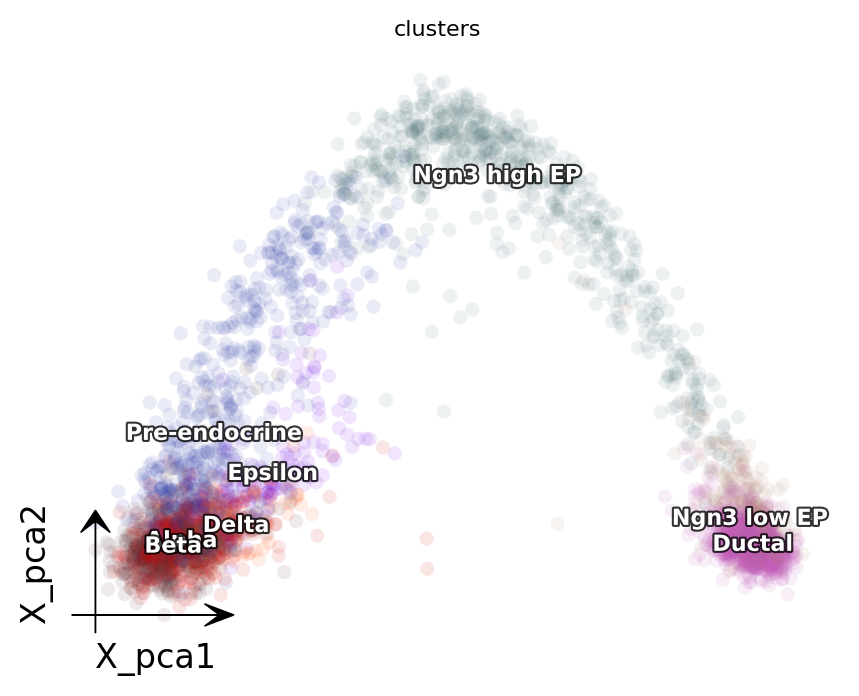

In [6]:
dyn.pl.pca(adata, color='clusters',pointsize=0.1)

In [7]:
adata.write(result_path+'EG_dyn.h5ad')